In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers

In [3]:
import os
import time
import datetime
import random
from google.colab import drive

import pandas as pd
import numpy as np
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import accuracy_score

from transformers import AutoModelForSequenceClassification
from transformers import AutoConfig
from transformers import AdamW
from transformers import AutoTokenizer
from transformers import get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns
import IPython

import torch
from torch.utils.data import TensorDataset, random_split
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

In [4]:
# Empty cache of GPU
torch.cuda.empty_cache()

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


## Load data

In [ ]:
# dataset
df =  pd.read_csv("/content/drive/MyDrive/preprocessed_lenta_titles.csv", encoding='UTF8', sep=",")
df.head()
dft1 = df[df['tags']=='Политика']
dft2 = df[df['tags']=='Украина']
dft3 = df[df['tags']=='Общество']
dfmerge = pd.concat([dft1, dft2, dft3])
dfmerge.head()

,Unnamed: 0,title,tags,text_lower,text_punct,text_stop,text_common,text_rare,text_nonum,text_token,text_lemm,text_ready
2,2,На Западе рассказали о нехватке Patriot для пе...,Политика,на западе рассказали о нехватке patriot для пе...,на западе рассказали о нехватке patriot для пе...,западе рассказали нехватке patriot передачи всу,западе нехватке patriot передачи,западе нехватке patriot передачи,западе нехватке patriot передачи,"['западе', 'нехватке', 'patriot', 'передачи']",запад нехватка patriot передача,запад рассказать нехватка patriot передача всу
4,4,Байден и Си Цзиньпин обсудили ситуацию вокруг ...,Политика,байден и си цзиньпин обсудили ситуацию вокруг ...,байден и си цзиньпин обсудили ситуацию вокруг ...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,"['байден', 'си', 'цзиньпин', 'обсудили', 'ситу...",байден си цзиньпин обсудить ситуация вокруг ti...,байден си цзиньпин обсудить ситуация вокруг ti...
9,9,Британия осудила Северную Корею из-за пуска ба...,Политика,британия осудила северную корею из-за пуска ба...,британия осудила северную корею изза пуска бал...,британия осудила северную корею изза пуска бал...,британия осудила северную корею пуска баллисти...,британия осудила северную корею пуска баллисти...,британия осудила северную корею пуска баллисти...,"['британия', 'осудила', 'северную', 'корею', '...",британия осудить северный корея пуск баллистич...,британия осудить северный корея из за пуск бал...
13,13,Запад создал план по сохранению поставок оружи...,Политика,запад создал план по сохранению поставок оружи...,запад создал план по сохранению поставок оружи...,запад создал план сохранению поставок оружия у...,запад создал план сохранению поставок оружия в...,запад создал план сохранению поставок оружия в...,запад создал план сохранению поставок оружия в...,"['запад', 'создал', 'план', 'сохранению', 'пос...",запад создать план сохранение поставка оружие ...,запад создать план сохранение поставка оружие ...
14,14,Близ Тайваня зафиксировали еще четыре землетря...,Политика,близ тайваня зафиксировали еще четыре землетря...,близ тайваня зафиксировали еще четыре землетря...,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,"['близ', 'тайваня', 'зафиксировали', 'четыре',...",близ тайвань зафиксировать четыре землетрясение,близ тайвань зафиксировать четыре землетрясение


In [ ]:
dfmerge = dfmerge.dropna()
dfmerge = dfmerge.dropna(subset = ['title'])

In [ ]:
import re
# Удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
#Удаление URL

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
#Удаление HTML-тегов
from bs4 import BeautifulSoup
#Function for removing html
def html(text):
    return BeautifulSoup(text, "lxml").text

In [ ]:
#Select a part of DataFrame
df = df.sample(frac=1)
df = df.head(1000)

In [ ]:
# Get the lists of sentences and their labels.
def categorise(row):
    if row['tags'] == 'Политика':
        return 0
    elif row['tags'] == 'Украина':
        return 1
    elif row['tags'] == 'Общество':
        return 2
dfmerge=dfmerge.dropna()
dfmerge['text_ready2'] = dfmerge['title'].apply(emoji)
dfmerge['text_ready2'] = dfmerge['text_ready2'].apply(remove_urls)
dfmerge['text_ready2'] = dfmerge['text_ready2'].apply(html)
dfmerge[['text_ready2']].head()
dfmerge['labels'] = dfmerge.apply(lambda row: categorise(row), axis=1)

<ipython-input-7-2f33bba9015d>:22: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "lxml").text


In [ ]:
dfmerge.head(10)

,Unnamed: 0,title,tags,text_lower,text_punct,text_stop,text_common,text_rare,text_nonum,text_token,text_lemm,text_ready,text_ready2,labels
2,2,На Западе рассказали о нехватке Patriot для пе...,Политика,на западе рассказали о нехватке patriot для пе...,на западе рассказали о нехватке patriot для пе...,западе рассказали нехватке patriot передачи всу,западе нехватке patriot передачи,западе нехватке patriot передачи,западе нехватке patriot передачи,"['западе', 'нехватке', 'patriot', 'передачи']",запад нехватка patriot передача,запад рассказать нехватка patriot передача всу,На Западе рассказали о нехватке Patriot для пе...,0
4,4,Байден и Си Цзиньпин обсудили ситуацию вокруг ...,Политика,байден и си цзиньпин обсудили ситуацию вокруг ...,байден и си цзиньпин обсудили ситуацию вокруг ...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,"['байден', 'си', 'цзиньпин', 'обсудили', 'ситу...",байден си цзиньпин обсудить ситуация вокруг ti...,байден си цзиньпин обсудить ситуация вокруг ti...,Байден и Си Цзиньпин обсудили ситуацию вокруг ...,0
9,9,Британия осудила Северную Корею из-за пуска ба...,Политика,британия осудила северную корею из-за пуска ба...,британия осудила северную корею изза пуска бал...,британия осудила северную корею изза пуска бал...,британия осудила северную корею пуска баллисти...,британия осудила северную корею пуска баллисти...,британия осудила северную корею пуска баллисти...,"['британия', 'осудила', 'северную', 'корею', '...",британия осудить северный корея пуск баллистич...,британия осудить северный корея из за пуск бал...,Британия осудила Северную Корею из-за пуска ба...,0
13,13,Запад создал план по сохранению поставок оружи...,Политика,запад создал план по сохранению поставок оружи...,запад создал план по сохранению поставок оружи...,запад создал план сохранению поставок оружия у...,запад создал план сохранению поставок оружия в...,запад создал план сохранению поставок оружия в...,запад создал план сохранению поставок оружия в...,"['запад', 'создал', 'план', 'сохранению', 'пос...",запад создать план сохранение поставка оружие ...,запад создать план сохранение поставка оружие ...,Запад создал план по сохранению поставок оружи...,0
14,14,Близ Тайваня зафиксировали еще четыре землетря...,Политика,близ тайваня зафиксировали еще четыре землетря...,близ тайваня зафиксировали еще четыре землетря...,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,близ тайваня зафиксировали четыре землетрясения,"['близ', 'тайваня', 'зафиксировали', 'четыре',...",близ тайвань зафиксировать четыре землетрясение,близ тайвань зафиксировать четыре землетрясение,Близ Тайваня зафиксировали еще четыре землетря...,0
19,19,На Западе рассказали о печальной судьбе Харькова,Политика,на западе рассказали о печальной судьбе харькова,на западе рассказали о печальной судьбе харькова,западе рассказали печальной судьбе харькова,западе печальной судьбе харькова,западе печальной судьбе харькова,западе печальной судьбе харькова,"['западе', 'печальной', 'судьбе', 'харькова']",запад печальный судьба харьков,запад рассказать печальный судьба харьков,На Западе рассказали о печальной судьбе Харькова,0
21,21,В США заявили о нежелании Вашингтона вступать ...,Политика,в сша заявили о нежелании вашингтона вступать ...,в сша заявили о нежелании вашингтона вступать ...,сша заявили нежелании вашингтона вступать прям...,нежелании вашингтона вступать прямое столкновение,нежелании вашингтона вступать прямое столкновение,нежелании вашингтона вступать прямое столкновение,"['нежелании', 'вашингтона', 'вступать', 'прямо...",нежелание вашингтон вступать прямой столкновение,сша заявить нежелание вашингтон вступать прямо...,В США заявили о нежелании Вашингтона вступать ...,0
27,27,В Минобороны рассказали об отношении россиян к...,Политика,в 

In [ ]:
dfmerge.sample(10)

,Unnamed: 0,title,tags,text_lower,text_punct,text_stop,text_common,text_rare,text_nonum,text_token,text_lemm,text_ready,text_ready2,labels
46751,46751,Появилось видео применения огнеметной системы ...,Украина,появилось видео применения огнеметной системы ...,появилось видео применения огнеметной системы ...,появилось видео применения огнеметной системы ...,появилось применения огнеметной системы солнце...,появилось применения огнеметной системы солнце...,появилось применения огнеметной системы солнце...,"['появилось', 'применения', 'огнеметной', 'сис...",появиться применение огнемётный система солнце...,появиться видео применение огнемётный система ...,Появилось видео применения огнеметной системы ...,1
63945,63945,Стало известно о спорах в ЕС из-за антироссийс...,Политика,стало известно о спорах в ес из-за антироссийс...,стало известно о спорах в ес изза антироссийск...,стало известно спорах ес изза антироссийских с...,спорах антироссийских санкций,спорах антироссийских санкций,спорах антироссийских санкций,"['спорах', 'антироссийских', 'санкций']",спор антироссийский санкция,стать известно спор ес из за антироссийский са...,Стало известно о спорах в ЕС из-за антироссийс...,0
1432,1432,Последствия атаки беспилотника на Белгород сня...,Общество,последствия атаки беспилотника на белгород сня...,последствия атаки беспилотника на белгород сня...,последствия атаки беспилотника белгород сняли ...,последствия атаки беспилотника белгород сняли,последствия атаки беспилотника белгород сняли,последствия атаки беспилотника белгород сняли,"['последствия', 'атаки', 'беспилотника', 'белг...",последствие атака беспилотник белгород снять,последствие атака беспилотник белгород снять в...,Последствия атаки беспилотника на Белгород сня...,2
6020,6020,В США назвали возможным вступление Украины в Н...,Политика,в сша назвали возможным вступление украины в н...,в сша назвали возможным вступление украины в н...,сша назвали возможным вступление украины нато ...,возможным вступление завершения конфликта,возможным вступление завершения конфликта,возможным вступление завершения конфликта,"['возможным', 'вступление', 'завершения', 'кон...",возможный вступление завершение конфликт,сша назвать возможный вступление украина нато ...,В США назвали возможным вступление Украины в Н...,0
9933,9933,Глава ЦИК ответила на вопрос о присутствии меж...,Политика,глава цик ответила на вопрос о присутствии меж...,глава цик ответила на вопрос о присутствии меж...,глава цик ответила вопрос присутствии междунар...,цик ответила вопрос присутствии международных ...,цик ответила вопрос присутствии международных ...,цик ответила вопрос присутствии международных ...,"['цик', 'ответила', 'вопрос', 'присутствии', '...",цик ответить вопрос присутствие международный ...,глава цик ответить вопрос присутствие междунар...,Глава ЦИК ответила на вопрос о присутствии меж...,0
18934,18934,На Украине мошенники вымогали деньги под видом...,Украина,на украине мошенники вымогали деньги под видом...,на украине мошенники вымогали деньги под видом...,украине мошенники вымогали деньги видом сотруд...,мошенники вымогали деньги видом сотрудников во...,мошенники вымогали деньги видом сотрудников во...,мошенники вымогали деньги видом сотрудников во...,"['мошенники', 'вымогали', 'деньги', 'видом', '...",мошенник вымогать деньга вид сотрудник военкомат,украина мошенник вымогать деньга вид сотрудник...,На Украине мошенники вымогали деньги под видом...,1
30821,30821,Глава крымского парламента призвал лишить Киев...,Политика,глава крымского парламента призвал лишить киев...,глава крымского парламента призвал лишить киев...,глава крымского парламента призвал лишить киев...,крымского парламента призвал лишить киев контр...,крымского парламента призвал лишить киев контр...,крымского парламента призвал лишить киев контр...,"['крымского', 'парламента', 'призвал', 'лишить...",крымский парламент призвать лишить киев контро...,глава крымский парламент призвать лишить киев ...,Глава крымского парламента призвал лиши

In [ ]:
texts = dfmerge.text_ready.values
labels = dfmerge.labels.values

## Tokenize Data

In [ ]:
model_name = "bert-base-multilingual-uncased"
MAX_INPUT_LENGTH = 192

In [ ]:
# Load the pretrained BERT tokenizer.
print(f"Loading {model_name} tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)

Loading bert-base-multilingual-uncased tokenizer...


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

In [ ]:
# Tokenize all of the sentences and map the tokens to their word IDs
input_ids = []
attention_masks = []

for text in texts:
    encoded_dict = tokenizer.encode_plus(
                        text,
                        add_special_tokens = True,
                        max_length = MAX_INPUT_LENGTH,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        return_tensors = 'pt')

    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2834: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [ ]:
# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels, dtype=torch.long)

# Print sentence 0, now as a list of IDs.
print('Original: ', texts[0])
print('Token IDs:', input_ids[0])
print('Attention Mask:', attention_masks[0]) # 1 for all text tokens, 0 for all padding tokens

Original:  запад рассказать нехватка patriot передача всу
Token IDs: tensor([  101, 30678, 89122, 17686, 10396, 10395, 17860, 10581, 75306, 90779,
        10185,   309, 16696,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,   

<ipython-input-21-1396884ff433>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long)


In [ ]:
# Combine the training inputs into a TensorDataset.
dataset = TensorDataset(input_ids, attention_masks, labels)

# Create a 80-10-10 train-validation-test split

# Calculate the number of samples to include in each set.
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Divide the dataset by randomly selecting samples.
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

print(f"{train_size} training samples")
print(f"{val_size} validation samples")
print(f"{test_size} test samples")

22478 training samples
2809 validation samples
2811 test samples


In [ ]:
# The DataLoader needs to know our batch size for training, so we specify it
# here. For fine-tuning BERT on a specific task, the authors recommend a batch
# size of 16 or 32.
batch_size = 32

# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
            train_dataset,
            sampler = RandomSampler(train_dataset),
            batch_size = batch_size
        )

# For validation the order doesn't matter, so we'll just read them sequentially.
validation_dataloader = DataLoader(
            val_dataset,
            sampler = SequentialSampler(val_dataset),
            batch_size = batch_size
        )

# For test the order doesn't matter, so we'll just read them sequentially.
test_dataloader = DataLoader(
            test_dataset,
            sampler = SequentialSampler(test_dataset),
            batch_size = batch_size
        )

## Create and Train Model

In [ ]:
# Load pretrained model for sequence classification
print(f"Loading {model_name} model...")
config = AutoConfig.from_pretrained(model_name)
config.num_labels = len(labels)
config.output_attentions = True
print("config", config)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config)

# Tell pytorch to run this model on the GPU.
model.cuda()

Выходные данные были обрезаны до нескольких последних строк (5000).
    "LABEL_5516": 5516,
    "LABEL_5517": 5517,
    "LABEL_5518": 5518,
    "LABEL_5519": 5519,
    "LABEL_552": 552,
    "LABEL_5520": 5520,
    "LABEL_5521": 5521,
    "LABEL_5522": 5522,
    "LABEL_5523": 5523,
    "LABEL_5524": 5524,
    "LABEL_5525": 5525,
    "LABEL_5526": 5526,
    "LABEL_5527": 5527,
    "LABEL_5528": 5528,
    "LABEL_5529": 5529,
    "LABEL_553": 553,
    "LABEL_5530": 5530,
    "LABEL_5531": 5531,
    "LABEL_5532": 5532,
    "LABEL_5533": 5533,
    "LABEL_5534": 5534,
    "LABEL_5535": 5535,
    "LABEL_5536": 5536,
    "LABEL_5537": 5537,
    "LABEL_5538": 5538,
    "LABEL_5539": 5539,
    "LABEL_554": 554,
    "LABEL_5540": 5540,
    "LABEL_5541": 5541,
    "LABEL_5542": 5542,
    "LABEL_5543": 5543,
    "LABEL_5544": 5544,
    "LABEL_5545": 5545,
    "LABEL_5546": 5546,
    "LABEL_5547": 5547,
    "LABEL_5548": 5548,
    "LABEL_5549": 5549,
    "LABEL_555": 555,
    "LABEL_5550": 5550,
    

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
# Get all of the model's parameters as a list of tuples.
params = list(model.named_parameters())

print('The model has {:} different named parameters.\n'.format(len(params)))

print('==== Embedding Layer ====\n')

for p in params[0:5]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== First Transformer ====\n')

for p in params[5:21]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== Output Layer ====\n')

for p in params[-4:]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

The model has 201 different named parameters.

==== Embedding Layer ====

bert.embeddings.word_embeddings.weight                  (105879, 768)
bert.embeddings.position_embeddings.weight                (512, 768)
bert.embeddings.token_type_embeddings.weight                (2, 768)
bert.embeddings.LayerNorm.weight                              (768,)
bert.embeddings.LayerNorm.bias                                (768,)

==== First Transformer ====

bert.encoder.layer.0.attention.self.query.weight          (768, 768)
bert.encoder.layer.0.attention.self.query.bias                (768,)
bert.encoder.layer.0.attention.self.key.weight            (768, 768)
bert.encoder.layer.0.attention.self.key.bias                  (768,)
bert.encoder.layer.0.attention.self.value.weight          (768, 768)
bert.encoder.layer.0.attention.self.value.bias                (768,)
bert.encoder.layer.0.attention.output.dense.weight        (768, 768)
bert.encoder.layer.0.attention.output.dense.bias              (768,

In [ ]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
# I believe the 'W' stands for 'Weight Decay fix"
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
# Number of training epochs. The BERT authors recommend between 2 and 4.
epochs = 3

# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [ ]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))


In [ ]:
# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using the
        # `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass. PyTorch doesn't do this automatically because
        # accumulating the gradients is "convenient while training RNNs".
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # The documentation for this `model` function is here:
        # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
        # It returns different numbers of parameters depending on what arguments
        # arge given and what flags are set. For our useage here, it returns
        # the loss (because we provided labels) and the "logits"--the model
        # outputs prior to activation.
        loss, logits, attentions = model(input_ids=b_input_ids,
                                         attention_mask=b_input_mask,
                                         labels=b_labels)
        output = model(b_input_ids, token_type_ids=None,
                     attention_mask=b_input_mask,
                     labels=b_labels)
        loss = output[0]
        logits = output[1]

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    print("")
    print("Running Validation...")

    t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()

    # Tracking variables
    total_eval_accuracy = 0
    total_eval_loss = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    for batch in validation_dataloader:

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using
        # the `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Tell pytorch not to bother with constructing the compute graph during
        # the forward pass, since this is only needed for backprop (training).
        with torch.no_grad():

            # Forward pass, calculate logit predictions.
            # token_type_ids is the same as the "segment ids", which
            # differentiates sentence 1 and 2 in 2-sentence tasks.
            # The documentation for this `model` function is here:
            # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
            # Get the "logits" output by the model. The "logits" are the output
            # values prior to applying an activation function like the softmax.
            (loss, logits, attentions) = model(input_ids=b_input_ids,
                                               attention_mask=b_input_mask,
                                               labels=b_labels)
        output = model(b_input_ids, token_type_ids=None,
                     attention_mask=b_input_mask,
                     labels=b_labels)
        loss = output[0]
        logits = output[1]
        # Accumulate the validation loss.
        total_eval_loss += loss.item()

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate the accuracy for this batch of test sentences, and
        # accumulate it over all batches.
        total_eval_accuracy += flat_accuracy(logits, label_ids)


    # Report the final accuracy for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    # Calculate the average loss over all of the batches.
    avg_val_loss = total_eval_loss / len(validation_dataloader)

    # Measure how long the validation run took.
    validation_time = format_time(time.time() - t0)

    print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_val_accuracy,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 3 ========
Training...


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


  Batch    40  of    703.    Elapsed: 0:00:49.
  Batch    80  of    703.    Elapsed: 0:01:39.
  Batch   120  of    703.    Elapsed: 0:02:32.
  Batch   160  of    703.    Elapsed: 0:03:25.
  Batch   200  of    703.    Elapsed: 0:04:18.
  Batch   240  of    703.    Elapsed: 0:05:11.
  Batch   280  of    703.    Elapsed: 0:06:04.
  Batch   320  of    703.    Elapsed: 0:06:57.
  Batch   360  of    703.    Elapsed: 0:07:50.
  Batch   400  of    703.    Elapsed: 0:08:43.
  Batch   440  of    703.    Elapsed: 0:09:36.
  Batch   480  of    703.    Elapsed: 0:10:28.
  Batch   520  of    703.    Elapsed: 0:11:21.
  Batch   560  of    703.    Elapsed: 0:12:14.
  Batch   600  of    703.    Elapsed: 0:13:08.
  Batch   640  of    703.    Elapsed: 0:14:00.
  Batch   680  of    703.    Elapsed: 0:14:53.

  Average training loss: 1.77
  Training epoch took: 0:15:23

Running Validation...
  Accuracy: 0.85
  Validation Loss: 0.44
  Validation took: 0:01:01

======== Epoch 2 / 3 ========
Training...
  Bat

In [ ]:
# Display floats with two decimal places.
#pd.set_option('precision', 2)

# Create a DataFrame from our training statistics.
df_stats = pd.DataFrame(data=training_stats)

# Use the 'epoch' as the row index.
df_stats = df_stats.set_index('epoch')

# Display the table.
df_stats

,Training Loss,Valid. Loss,Valid. Accur.,Training Time,Validation Time
epoch,,,,,
1,1.768545,0.436967,0.846449,0:15:23,0:01:01
2,0.426950,0.406639,0.849489,0:15:30,0:01:01
3,0.350466,0.400395,0.858267,0:15:29,0:01:01


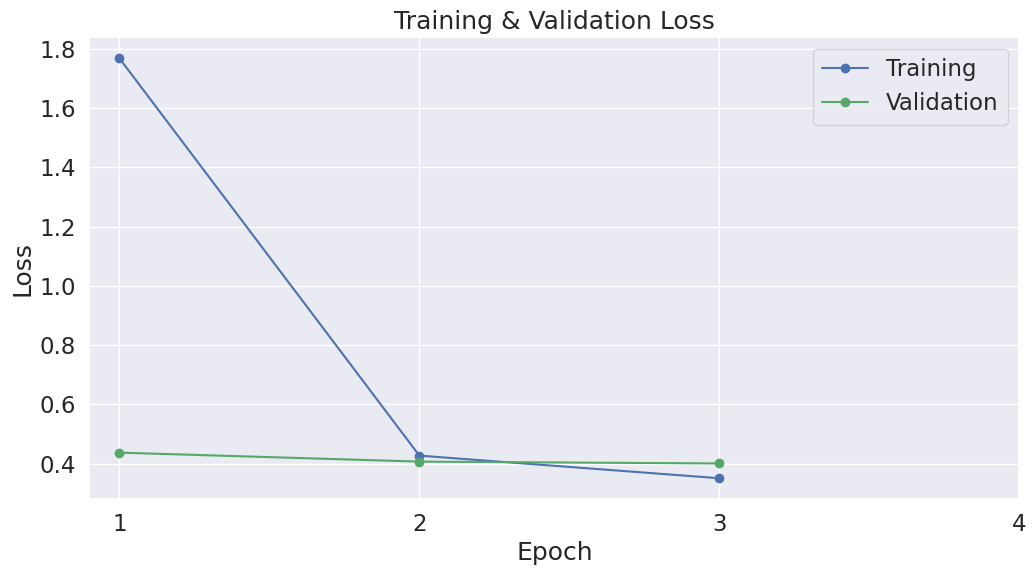

In [ ]:
import matplotlib.pyplot as plt
#% matplotlib inline

import seaborn as sns

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

# Label the plot.
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks([1, 2, 3, 4])

plt.show()

## Evaluation on Test Set

In [ ]:
# Prediction on test set

print("Predicting labels ...")

# Put model in evaluation mode
model.eval()

# Tracking variables
predictions , true_labels = [], []

# Predict
for batch in test_dataloader:
  # Add batch to GPU
  batch = tuple(t.to(device) for t in batch)

  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask, b_labels = batch

  # Telling the model not to compute or store gradients, saving memory and
  # speeding up prediction
  with torch.no_grad():
      # Forward pass, calculate logit predictions
      #outputs = model(input_ids=b_input_ids,
      #                attention_mask=b_input_mask)
      output = model(b_input_ids, token_type_ids=None,
                     attention_mask=b_input_mask,
                     labels=b_labels)
  loss = output[0]
  logits = output[1]

  # Move logits and labels to CPU
  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  # Store predictions and true labels
  predictions.extend(logits)
  true_labels.extend(label_ids)

print(f"Predicted {len(predictions)} samples")

Predicting labels ...
Predicted 2811 samples


In [ ]:
predictions = np.argmax(predictions, axis=1)
print(f"Test set accuracy: {accuracy_score(true_labels, predictions)}")
print(f"Test set Matthews correlation coefficient: {matthews_corrcoef(true_labels, predictions)}")

Test set accuracy: 0.8491639985770189
Test set Matthews correlation coefficient: 0.72789694023431


## Save model to disk

In [9]:
# Saving best-practices: if you use defaults names for the model, you can reload it using from_pretrained()

output_dir = f"./drive/MyDrive/bert-base-multilingual-uncased/"

# Create output directory if needed
#if not os.path.exists(output_dir):
    #os.makedirs(output_dir)

#print(f"Saving model to {output_dir}")

# Save a trained model, configuration and tokenizer using `save_pretrained()`.
# They can then be reloaded using `from_pretrained()`
#model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
#model_to_save.save_pretrained(output_dir)
#tokenizer.save_pretrained(output_dir)

# Good practice: save your training arguments together with the trained model
#torch.save(args, os.path.join(output_dir, 'training_args.bin'))


In [ ]:
# Mount Google Drive to this Notebook instance.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Copy the model files to a directory in your Google Drive.
#target_dir = f"\"./drive/My Drive/NLP/BERT CLF 10kGNAD/\"" multi_cased_L-12_H-768_A-12
#target_dir = f"\"./bert-base-multilingual-uncased CLF 10kGNAD/\""
target_dir = f"\"./drive/My Drive/multi_cased_L-12_H-768_A-12 CLF 10kGNAD/\""
!cp -r $output_dir $target_dir

## Load Model from Drive

In [11]:
from google.colab import drive

#drive.mount('/content/drive', force_remount=True)
#output_dir = f"./drive/My Drive/NLP_BERT CLF 10kGNAD/{model_name}/"
output_dir = f"./drive/MyDrive/bert-base-multilingual-uncased/"
#output_dir = f"./drive/My Drive/multi_cased_L-12_H-768_A-12 CLF 10kGNAD/{model_name}/"
# Load a trained model and vocabulary that you have fine-tuned
model = AutoModelForSequenceClassification.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained(output_dir)

# Copy the model to the GPU.
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

## Predict on some sample text

### Prediction

In [29]:
texts = ["{США призвали Европу не вмешиваться в выборы президента в России}"]

In [30]:
input_ids = []
attention_masks = []

for text in texts:
  encoded_dict = tokenizer.encode_plus(
                          text,
                          add_special_tokens = True,
                          max_length = 64,
                          padding='max_length',
                          return_attention_mask = True,
                          return_tensors = 'pt')

  # Add the encoded sentence to the list.
  input_ids.append(encoded_dict['input_ids'])

  # And its attention mask (simply differentiates padding from non-padding).
  attention_masks.append(encoded_dict['attention_mask'])

  # Convert the lists into tensors.
  input_ids = torch.cat(input_ids, dim=0)
  attention_masks = torch.cat(attention_masks, dim=0)
print(input_ids)
print(input_ids)


tensor([[  101,   169,   100, 48888, 16548,   100, 10396,   309, 14597, 43853,
         46790,   309, 86748, 21911,   309,   100,   171,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]])
tensor([[  101,   169,   100, 48888, 16548,   100, 10396,   309, 14597, 43853,
         46790,   309, 86748, 21911,   309,   100,   171,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             

In [31]:
# Put model in evaluation mode
model.eval()

predictions = []
last_layer_attentions = []

# Move input ids and attention masks to GPU
input_ids = input_ids.to(device)
attention_masks = attention_masks.to(device)

for i in range(len(input_ids)):

  ids = input_ids[i].unsqueeze(0)
  masks = attention_masks[i].unsqueeze(0)

  with torch.no_grad():
      # Forward pass, calculate logit predictions
      outputs = model(input_ids=ids,
                      attention_mask=masks)

  # Get logits and compute softmax
  logits = outputs[0]
  logits = torch.softmax(logits,dim=1)
  last_layer_attention = outputs[1][-1]

  # Move logits and labels to CPU
  logits = logits.detach().cpu().numpy()
  last_layer_attention = last_layer_attention.detach().cpu().numpy()

  last_layer_attentions.append(last_layer_attention)
  predictions.append(logits)

In [32]:
probs = predictions[0][0]
print("text:", texts[0])
print("predictions:", probs)
pred_idx = np.argmax(probs)
print(f"Prediction: {texts[pred_idx]} ({probs[pred_idx]:.2f})", )

text: {США призвали Европу не вмешиваться в выборы президента в России}
predictions: [8.8795644e-01 8.5825458e-02 2.2235472e-02 ... 2.5387587e-07 1.7651685e-07
 9.5302383e-08]
Prediction: {США призвали Европу не вмешиваться в выборы президента в России} (0.89)


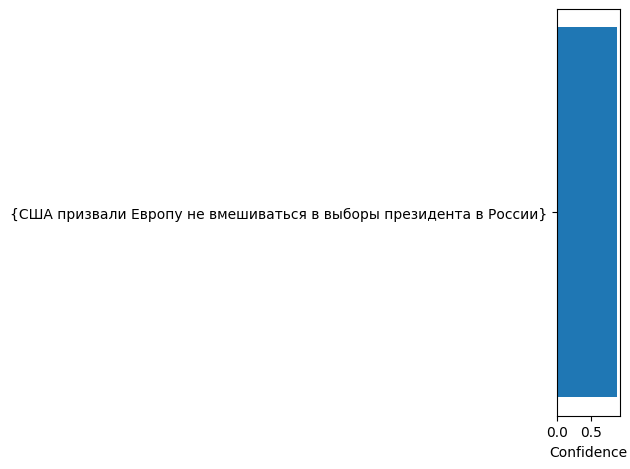

In [33]:
fig = plt.figure(tight_layout=True)
ax = fig.add_subplot(1, 1, 1)

y_pos = np.arange(len(texts))
confidences = [probs[i] for i in range(len(texts))]

ax.barh(y_pos, confidences, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(texts)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Confidence')

fig.show()

### Visualize Attentions

For each token, visualize the average over all 12 heads of the last layer's attention to the special character [CLS]. The darker the background of the token, the higher its attention

In [20]:
lla = last_layer_attentions[0][0][:,0,:]

In [21]:
def avg_token_attentions(last_layer_attentions):
  return last_layer_attentions.mean(axis=0)

In [22]:
avg_token_atts = avg_token_attentions(lla)
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

In [35]:
def handle_special_token_attentions(tokens, avg_token_atts):
  new_tokens = []
  new_avg_token_atts = []
  for i in range(len(tokens)):
    if tokens[i].startswith("[") or tokens[i].startswith("##"):
      continue
    if i < tokenizer.model_max_length - 1 and tokens[i+1].startswith("##"):
      merged_tokens = tokens[i] + tokens[i+1][2:]
      atts = [avg_token_atts[i], avg_token_atts[i+1]]
      i += 1
      while i < tokenizer.model_max_length - 1 and tokens[i+1].startswith("##"):
        merged_tokens += tokens[i+1][2:]
        atts.append(avg_token_atts[i+1])
        i += 1
      new_tokens.append(merged_tokens)
      new_avg_token_atts.append(sum(atts)/len(atts))
    elif i < tokenizer.model_max_length - 1:
      new_tokens.append(tokens[i])
      new_avg_token_atts.append(avg_token_atts[i])
  new_avg_token_atts = new_avg_token_atts / sum(new_avg_token_atts)
  return new_tokens, new_avg_token_atts

In [36]:
tokens, avg_token_atts = handle_special_token_attentions(tokens, avg_token_atts)

In [37]:
for token, att in zip(tokens, avg_token_atts):
  print(token, att)

{ 0.14590038768171526
заявили 0.099819950006429
об 0.047206467092607944
окончании 0.09347345462358973
поставок 0.20463522888967742
оружия 0.2432539168486613
} 0.16571059485731937


In [38]:
def scale_color_h_hex(c_h, scale):
    return matplotlib.colors.to_hex(
        matplotlib.colors.hsv_to_rgb((c_h, scale, 1)))

def blue_background_hex(scale):
    return scale_color_h_hex(0.625, scale)

In [39]:
att_html = "<table><tr>"
for token, att in zip(tokens, avg_token_atts):
  att_html += "<td>"
  att_html += "<span style=\"background-color: " + blue_background_hex(att) + "\">" + token + "</span>"
  att_html += "</td>"
att_html += "</tr>"

In [40]:
IPython.display.HTML(att_html)

{,заявили,об,окончании,поставок,оружия,}
